<a href="https://colab.research.google.com/github/Series-Parallel/Machine_in_Deep_Learning/blob/main/U_net_implementation_from_scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn.functional as F

### Softmax

In [2]:
logits = torch.randn(1, 2, 388, 388)

probs = F.softmax(logits, dim=1)

print(probs.shape)

torch.Size([1, 2, 388, 388])


In [3]:
pixel_sum = probs.sum(dim=1)

print(pixel_sum.shape)
print(pixel_sum[0,100,100])

torch.Size([1, 388, 388])
tensor(1.0000)


### Cross entropy


In [4]:
logits = torch.randn(1, 2, 388, 388)
mask = torch.randint(0, 2, (1, 388, 388))

In [5]:
loss = F.cross_entropy(logits, mask)
print(loss)

tensor(0.9037)


### distance form


In [6]:
import numpy as np

In [7]:
mask = np.zeros((10,10))

mask[2:5,2:5] = 1
mask[6:9,6:9] = 1

print(mask)

[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 1. 1. 0. 0. 0. 0. 0.]
 [0. 0. 1. 1. 1. 0. 0. 0. 0. 0.]
 [0. 0. 1. 1. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 1. 1. 0.]
 [0. 0. 0. 0. 0. 0. 1. 1. 1. 0.]
 [0. 0. 0. 0. 0. 0. 1. 1. 1. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]


In [8]:
from scipy.ndimage import distance_transform_edt

In [9]:
dist = distance_transform_edt(mask == 0)

print(dist)

[[2.82842712 2.23606798 2.         2.         2.         2.23606798
  2.82842712 3.60555128 4.47213595 5.38516481]
 [2.23606798 1.41421356 1.         1.         1.         1.41421356
  2.23606798 3.16227766 4.12310563 5.09901951]
 [2.         1.         0.         0.         0.         1.
  2.         3.         4.         4.12310563]
 [2.         1.         0.         0.         0.         1.
  2.         3.         3.         3.16227766]
 [2.         1.         0.         0.         0.         1.
  2.         2.         2.         2.23606798]
 [2.23606798 1.41421356 1.         1.         1.         1.41421356
  1.         1.         1.         1.41421356]
 [2.82842712 2.23606798 2.         2.         2.         1.
  0.         0.         0.         1.        ]
 [3.60555128 3.16227766 3.         3.         2.         1.
  0.         0.         0.         1.        ]
 [4.47213595 4.12310563 4.         3.         2.         1.
  0.         0.         0.         1.        ]
 [5.38516481 

In [10]:
mask = np.zeros((10,10))

mask[2:5,2:5] = 1
mask[6:9,6:9] = 1

print(mask)

[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 1. 1. 0. 0. 0. 0. 0.]
 [0. 0. 1. 1. 1. 0. 0. 0. 0. 0.]
 [0. 0. 1. 1. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 1. 1. 0.]
 [0. 0. 0. 0. 0. 0. 1. 1. 1. 0.]
 [0. 0. 0. 0. 0. 0. 1. 1. 1. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]


In [11]:
from scipy.ndimage import label

In [12]:
labeled_mask, num_cells = label(mask)

print(labeled_mask)
print(num_cells)

[[0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 1 1 1 0 0 0 0 0]
 [0 0 1 1 1 0 0 0 0 0]
 [0 0 1 1 1 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 2 2 2 0]
 [0 0 0 0 0 0 2 2 2 0]
 [0 0 0 0 0 0 2 2 2 0]
 [0 0 0 0 0 0 0 0 0 0]]
2


### core algorith step

In [13]:
from scipy.ndimage import label, distance_transform_edt

In [14]:
mask = np.zeros((10,10))
mask[2:5,2:5] = 1
mask[6:9,6:9] = 1

In [15]:
labeled_mask, num_cells = label(mask)

print(num_cells)

2


In [16]:
distance_maps = []

for cell_id in range(1, num_cells+1):

    cell_mask = labeled_mask == cell_id

    distance = distance_transform_edt(~cell_mask)

    distance_maps.append(distance)

distance_maps = np.stack(distance_maps)

In [17]:
sorted_distances = np.sort(distance_maps, axis=0)

d1 = sorted_distances[0]
d2 = sorted_distances[1]

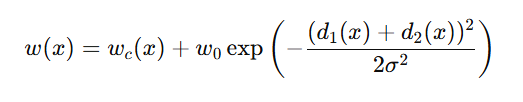

In [18]:
w0 = 10
sigma = 5

boundary_weight = w0 * np.exp(-((d1 + d2)**2) / (2 * sigma**2))

In [19]:
wc = np.ones_like(boundary_weight)

weight_map = wc + boundary_weight

### loss
loss(pixel) = weight(pixel) * cross_entropy(pixel)

In [20]:
import torch

In [21]:

weight_map = torch.tensor(weight_map, dtype=torch.float32)
weight_map = weight_map.unsqueeze(0)  # add batch dimension

In [22]:
logits = torch.randn(1, 2, mask.shape[0], mask.shape[1])
mask_tensor = torch.tensor(mask, dtype=torch.long).unsqueeze(0)
loss = F.cross_entropy(logits, mask_tensor, reduction="none")

## architecture

In [23]:
import torch.nn as nn

class DoubleConv(nn.Module):

    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)

In [24]:
block = DoubleConv(1, 64)

x = torch.randn(1, 1, 572, 572)

y = block(x)

print(y.shape)

torch.Size([1, 64, 568, 568])


In [25]:
down1 = DoubleConv(1, 64)
pool = nn.MaxPool2d(2)

In [26]:
x = torch.randn(1, 1, 572, 572)

x1 = down1(x)
print("after conv:", x1.shape)

x2 = pool(x1)
print("after pool:", x2.shape)

after conv: torch.Size([1, 64, 568, 568])
after pool: torch.Size([1, 64, 284, 284])


In [27]:
down1 = DoubleConv(1, 64)
down2 = DoubleConv(64, 128)

pool = nn.MaxPool2d(2)

x = torch.randn(1, 1, 572, 572)

x1 = down1(x)
print("after down1:", x1.shape)

x2 = pool(x1)
print("after pool1:", x2.shape)

x3 = down2(x2)
print("after down2:", x3.shape)

x4 = pool(x3)
print("after pool2:", x4.shape)

after down1: torch.Size([1, 64, 568, 568])
after pool1: torch.Size([1, 64, 284, 284])
after down2: torch.Size([1, 128, 280, 280])
after pool2: torch.Size([1, 128, 140, 140])


In [28]:
down3 = DoubleConv(128, 256)
down4 = DoubleConv(256, 512)
bottleneck = DoubleConv(512, 1024)

x5 = down3(x4)
print("after down3:", x5.shape)

x6 = pool(x5)
print("after pool3:", x6.shape)

x7 = down4(x6)
print("after down4:", x7.shape)

x8 = pool(x7)
print("after pool4:", x8.shape)

x9 = bottleneck(x8)
print("bottleneck:", x9.shape)

after down3: torch.Size([1, 256, 136, 136])
after pool3: torch.Size([1, 256, 68, 68])
after down4: torch.Size([1, 512, 64, 64])
after pool4: torch.Size([1, 512, 32, 32])
bottleneck: torch.Size([1, 1024, 28, 28])


left side done!

now we do right side!


In [29]:
upconv1 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)

x_up = upconv1(x9)

print("after upconv1:", x_up.shape)

after upconv1: torch.Size([1, 512, 56, 56])


In [30]:
upconv1 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)

x_up = upconv1(x9)

print("after upconv1:", x_up.shape)

after upconv1: torch.Size([1, 512, 56, 56])


In [31]:
x7_crop = x7[:, :, 4:60, 4:60]

print(x7_crop.shape)

torch.Size([1, 512, 56, 56])


In [32]:
x_concat = torch.cat([x7_crop, x_up], dim=1)

print(x_concat.shape)

torch.Size([1, 1024, 56, 56])


In [33]:
up_block1 = DoubleConv(1024, 512)

x10 = up_block1(x_concat)

print("after up_block1:", x10.shape)

after up_block1: torch.Size([1, 512, 52, 52])


In [34]:
upconv2 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)

x_up2 = upconv2(x10)

print("after upconv2:", x_up2.shape)

after upconv2: torch.Size([1, 256, 104, 104])


In [35]:
x5_crop = x5[:, :, 16:120, 16:120]

print("skip feature:", x5_crop.shape)

skip feature: torch.Size([1, 256, 104, 104])


In [36]:
x_concat2 = torch.cat([x5_crop, x_up2], dim=1)

print("after concat:", x_concat2.shape)

after concat: torch.Size([1, 512, 104, 104])


In [37]:
up_block2 = DoubleConv(512, 256)

x11 = up_block2(x_concat2)

print("after up_block2:", x11.shape)

after up_block2: torch.Size([1, 256, 100, 100])


In [38]:
print("after upconv2:", x_up2.shape)

after upconv2: torch.Size([1, 256, 104, 104])


In [39]:
x5_crop = x5[:, :, 16:120, 16:120]

print(x5_crop.shape)

torch.Size([1, 256, 104, 104])


In [40]:
x_concat2 = torch.cat([x5_crop, x_up2], dim=1)

print(x_concat2.shape)

torch.Size([1, 512, 104, 104])


In [41]:
up_block2 = DoubleConv(512, 256)

x11 = up_block2(x_concat2)

print(x11.shape)

torch.Size([1, 256, 100, 100])


In [42]:
upconv3 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)

x_up3 = upconv3(x11)

print("after upconv3:", x_up3.shape)

after upconv3: torch.Size([1, 128, 200, 200])


In [43]:
x3_crop = x3[:, :, 40:240, 40:240]

print(x3_crop.shape)

torch.Size([1, 128, 200, 200])


In [44]:
x_concat3 = torch.cat([x3_crop, x_up3], dim=1)

print(x_concat3.shape)

torch.Size([1, 256, 200, 200])


In [45]:
up_block3 = DoubleConv(256, 128)

x12 = up_block3(x_concat3)

print("after up_block3:", x12.shape)

after up_block3: torch.Size([1, 128, 196, 196])


In [46]:
print("after upconv3:", x_up3.shape)

after upconv3: torch.Size([1, 128, 200, 200])


In [47]:
x3_crop = x3[:, :, 40:240, 40:240]

print("skip feature:", x3_crop.shape)

skip feature: torch.Size([1, 128, 200, 200])


In [48]:
x_concat3 = torch.cat([x3_crop, x_up3], dim=1)

print("after concat:", x_concat3.shape)

after concat: torch.Size([1, 256, 200, 200])


In [49]:
up_block3 = DoubleConv(256, 128)

x12 = up_block3(x_concat3)

print("after up_block3:", x12.shape)

after up_block3: torch.Size([1, 128, 196, 196])


In [50]:
print("after up_block3:", x12.shape)

after up_block3: torch.Size([1, 128, 196, 196])


In [51]:
upconv4 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)

x_up4 = upconv4(x12)

print("after upconv4:", x_up4.shape)

after upconv4: torch.Size([1, 64, 392, 392])


In [52]:
x1_crop = x1[:, :, 88:480, 88:480]

print("skip feature:", x1_crop.shape)

skip feature: torch.Size([1, 64, 392, 392])


In [53]:
x_concat4 = torch.cat([x1_crop, x_up4], dim=1)

print("after concat:", x_concat4.shape)

after concat: torch.Size([1, 128, 392, 392])


In [54]:
up_block4 = DoubleConv(128, 64)

x13 = up_block4(x_concat4)

print("after up_block4:", x13.shape)

after up_block4: torch.Size([1, 64, 388, 388])


In [55]:
final_conv = nn.Conv2d(64, 2, kernel_size=1)

output = final_conv(x13)

print("final output:", output.shape)

final output: torch.Size([1, 2, 388, 388])


In [56]:
print("after upconv4:", x_up4.shape)

after upconv4: torch.Size([1, 64, 392, 392])


In [57]:
x1_crop = x1[:, :, 88:480, 88:480]

print("skip feature:", x1_crop.shape)

skip feature: torch.Size([1, 64, 392, 392])


In [58]:
x_concat4 = torch.cat([x1_crop, x_up4], dim=1)

print("after concat:", x_concat4.shape)

after concat: torch.Size([1, 128, 392, 392])


In [59]:
up_block4 = DoubleConv(128, 64)

x13 = up_block4(x_concat4)

print("after up_block4:", x13.shape)

after up_block4: torch.Size([1, 64, 388, 388])


In [60]:
final_conv = nn.Conv2d(64, 2, kernel_size=1)

output = final_conv(x13)

print("final output:", output.shape)

final output: torch.Size([1, 2, 388, 388])


In [61]:
print("final output:", output.shape)

final output: torch.Size([1, 2, 388, 388])


# will create the unet class!

In [62]:
class UNet(nn.Module):

    def __init__(self):
        super().__init__()

        # Encoder
        self.down1 = DoubleConv(1, 64)
        self.down2 = DoubleConv(64, 128)
        self.down3 = DoubleConv(128, 256)
        self.down4 = DoubleConv(256, 512)

        self.pool = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = DoubleConv(512, 1024)

        # Decoder
        self.upconv1 = nn.ConvTranspose2d(1024, 512, 2, stride=2)
        self.upconv2 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.upconv3 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.upconv4 = nn.ConvTranspose2d(128, 64, 2, stride=2)

        self.up1 = DoubleConv(1024, 512)
        self.up2 = DoubleConv(512, 256)
        self.up3 = DoubleConv(256, 128)
        self.up4 = DoubleConv(128, 64)

        # Final layer
        self.final = nn.Conv2d(64, 2, kernel_size=1)

    def forward(self, x):

      # Encoder
      x1 = self.down1(x)
      x2 = self.pool(x1)

      x3 = self.down2(x2)
      x4 = self.pool(x3)

      x5 = self.down3(x4)
      x6 = self.pool(x5)

      x7 = self.down4(x6)
      x8 = self.pool(x7)

      # Bottleneck
      x9 = self.bottleneck(x8)

      # Decoder stage 1
      x_up1 = self.upconv1(x9)
      x7_crop = x7[:, :, 4:60, 4:60]
      x_concat1 = torch.cat([x7_crop, x_up1], dim=1)
      x10 = self.up1(x_concat1)

      # Decoder stage 2
      x_up2 = self.upconv2(x10)
      x5_crop = x5[:, :, 16:120, 16:120]
      x_concat2 = torch.cat([x5_crop, x_up2], dim=1)
      x11 = self.up2(x_concat2)

      # Decoder stage 3
      x_up3 = self.upconv3(x11)
      x3_crop = x3[:, :, 40:240, 40:240]
      x_concat3 = torch.cat([x3_crop, x_up3], dim=1)
      x12 = self.up3(x_concat3)

      # Decoder stage 4
      x_up4 = self.upconv4(x12)
      x1_crop = x1[:, :, 88:480, 88:480]
      x_concat4 = torch.cat([x1_crop, x_up4], dim=1)
      x13 = self.up4(x_concat4)

      # Final output
      output = self.final(x13)

      return output

In [63]:
model = UNet()

In [64]:
x = torch.randn(1, 1, 572, 572)

y = model(x)

print(y.shape)

torch.Size([1, 2, 388, 388])


In [76]:
from torch.utils.data import Dataset
import torchvision.transforms as transforms
from PIL import Image
import torch
import numpy as np
import os


In [81]:
class SegmentationDataset(Dataset):

    def __init__(self, image_dir, mask_dir):

        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.images = [f for f in os.listdir(image_dir) if f.endswith(".jpg")]

        self.image_transform = transforms.Compose([
            transforms.Resize((572, 572)),
            transforms.ToTensor()
        ])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        img_name = self.images[idx]

        img_path = os.path.join(self.image_dir, img_name)
        mask_path = os.path.join(self.mask_dir, img_name.replace(".jpg", ".png"))

        # Load image
        image = Image.open(img_path).convert("L")

        # Load mask
        mask = Image.open(mask_path)

        # Resize image
        image = self.image_transform(image)

        # Resize mask (IMPORTANT: use NEAREST)
        mask = mask.resize((572, 572), Image.NEAREST)

        # Convert mask to tensor
        mask = torch.tensor(np.array(mask), dtype=torch.long)

        # Convert dataset labels to binary segmentation
        mask[mask == 2] = 1
        mask[mask == 3] = 0

        return image, mask

In [67]:
!wget https://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz
!wget https://www.robots.ox.ac.uk/~vgg/data/pets/data/annotations.tar.gz

--2026-03-14 14:38:00--  https://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz
Resolving www.robots.ox.ac.uk (www.robots.ox.ac.uk)... 129.67.94.2
Connecting to www.robots.ox.ac.uk (www.robots.ox.ac.uk)|129.67.94.2|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://thor.robots.ox.ac.uk/pets/images.tar.gz [following]
--2026-03-14 14:38:01--  https://thor.robots.ox.ac.uk/pets/images.tar.gz
Resolving thor.robots.ox.ac.uk (thor.robots.ox.ac.uk)... 129.67.95.98
Connecting to thor.robots.ox.ac.uk (thor.robots.ox.ac.uk)|129.67.95.98|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 791918971 (755M) [application/octet-stream]
Saving to: ‘images.tar.gz’

images.tar.gz       100%[===================>] 755.23M  25.7MB/s    in 31s     

2026-03-14 14:38:33 (24.3 MB/s) - ‘images.tar.gz’ saved [791918971/791918971]

--2026-03-14 14:38:33--  https://www.robots.ox.ac.uk/~vgg/data/pets/data/annotations.tar.gz
Resolving www.r

In [68]:
!tar -xzf images.tar.gz
!tar -xzf annotations.tar.gz

In [69]:
from torch.utils.data import DataLoader


In [82]:
dataset = SegmentationDataset(
    "images",
    "annotations/trimaps"
)

loader = DataLoader(dataset, batch_size=2, shuffle=True)

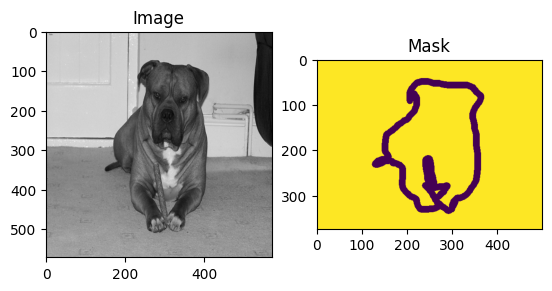

In [71]:
import matplotlib.pyplot as plt

img, mask = dataset[0]

plt.subplot(1,2,1)
plt.title("Image")
plt.imshow(img.squeeze(), cmap="gray")

plt.subplot(1,2,2)
plt.title("Mask")
plt.imshow(mask)

In [80]:
img, mask = dataset[0]

print(img.shape)
print(mask.shape)

torch.Size([1, 572, 572])
torch.Size([572, 572])


In [72]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)
model = model.to(device)

cuda


In [74]:
import torch.optim as optim
import torch.nn.functional as F

In [83]:
optimizer = optim.Adam(model.parameters(), lr=1e-4)

for epoch in range(5):

    for images, masks in loader:

        images = images.to(device)
        masks = masks.to(device)

        preds = model(images)

        # crop masks to match output
        masks = masks[:, 92:480, 92:480]

        loss = F.cross_entropy(preds, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print("epoch:", epoch, "loss:", loss.item())

epoch: 0 loss: 0.2597634494304657
epoch: 1 loss: 0.2165515124797821
epoch: 2 loss: 0.30168628692626953
epoch: 3 loss: 0.226814866065979
epoch: 4 loss: 0.23641584813594818


model took 1 hr 55 mins to train. damn!!


### testing


In [85]:
model.eval()

UNet(
  (down1): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1))
      (3): ReLU(inplace=True)
    )
  )
  (down2): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1))
      (3): ReLU(inplace=True)
    )
  )
  (down3): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1))
      (3): ReLU(inplace=True)
    )
  )
  (down4): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1))
      (3): ReLU(inplace=True)
    )
  )
  (pool): MaxPool2d(kernel_s

In [86]:
import matplotlib.pyplot as plt

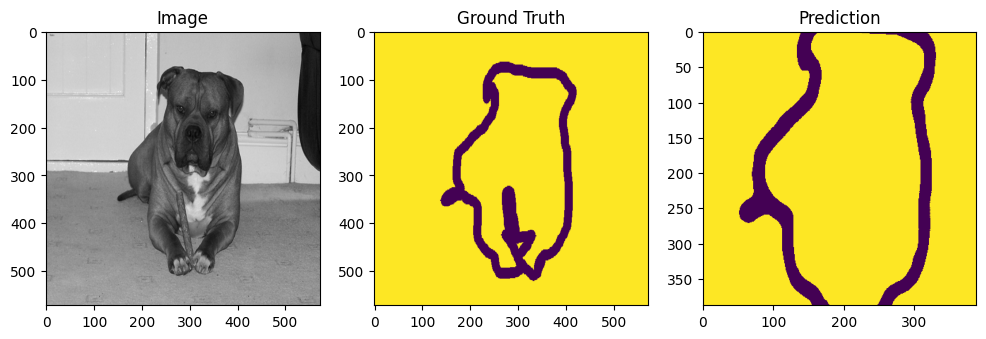

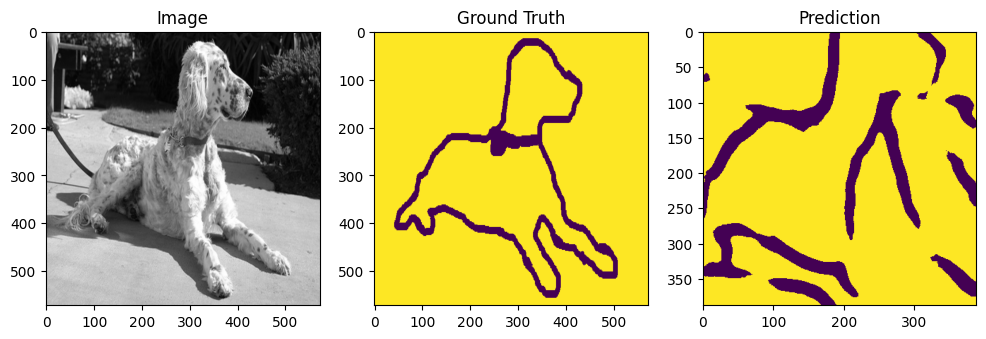

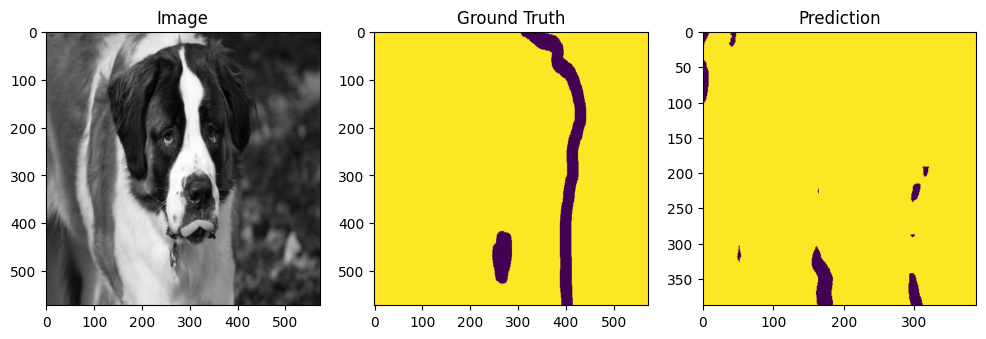

In [87]:
for i in range(3):

    img, mask = dataset[i]

    with torch.no_grad():
        pred = model(img.unsqueeze(0).to(device))

    pred = pred.argmax(dim=1).squeeze().cpu()

    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.title("Image")
    plt.imshow(img.squeeze(), cmap="gray")

    plt.subplot(1,3,2)
    plt.title("Ground Truth")
    plt.imshow(mask)

    plt.subplot(1,3,3)
    plt.title("Prediction")
    plt.imshow(pred)

    plt.show()